# HSI Datasets Downloading

In this document we will downloading and famliarizing with differents datasets for hyperspectral image classification. 

Sources

[1] [Indian Pines, Salinas, Pavia, Cuprite, KSC and Botswana datasets link](https://www.ehu.eus/ccwintco/index.php/Hyperspectral_Remote_Sensing_Scenes)

## Indian Pines

Is a dataset of hyperspectral images of the Indian Pines, Indiana region, obtained by the AVIRIS sensor (Airbone Visible/Infrared Imaging Spectrometer) of NASA in 1992.    

| Characteristic | Value |
| :--- | :--- |
| Number of categories | 16 |
| Data size | 145 x 145 pixels |
| Spectral bands | 220 |
| Number of pixels | 10 249 |
| Spatial Resolution | 20 meters per pixel |
| Wavelength range | 400 - 2500 nm |

This dataset contains 16 clases of vegetation and soil types.

| Class | Name |
| :--- | :--- |
| 1 | Alfalfa |
| 2 | Corn-notill |
| 3 | Corn-mintil |
| 4 | Corn |
| 5 | Grass-pasture |
| 6 | Grass-trees |
| 7 | Grass-pasture-mowed |
| 8 | Hay-windrowed |
| 9 | Oats |
| 10 | Soybean-notill |
| 11 | Soybean-mintil |
| 12 | Soybean-clean |
| 13 | Wheat |
| 14 | Woods |
| 15 | Buildings-grass-trees-drives |
| 16 | Stone-steel towers |


### Downloading
For download this dataset execute the followinng code block:

In [13]:
import scipy.io
import os
import requests

DATASETS_FOLDER = "/home/edwinacevedo/datasets/hsi"

if not os.path.exists(DATASETS_FOLDER):
    os.makedirs(DATASETS_FOLDER)

def download_file(url, filename):
    if not os.path.exists(filename):
        response = requests.get(url)
        with open(filename, 'wb') as f:
            f.write(response.content)
        print(f"Downloaded {filename}")
    else:
        print(f"{filename} already exists")

# URLs for Indian Pines dataset
data_url = 'http://www.ehu.eus/ccwintco/uploads/6/67/Indian_pines_corrected.mat'
gt_url = 'http://www.ehu.eus/ccwintco/uploads/c/c4/Indian_pines_gt.mat'

download_file(data_url, DATASETS_FOLDER + '/Indian_pines_corrected.mat')
download_file(gt_url, DATASETS_FOLDER + '/Indian_pines_gt.mat')

# Load the data
indian_pines = scipy.io.loadmat(DATASETS_FOLDER + '/Indian_pines_corrected.mat')['indian_pines_corrected']
indian_pines_gt = scipy.io.loadmat(DATASETS_FOLDER + '/Indian_pines_gt.mat')['indian_pines_gt']

print(f"Data shape: {indian_pines.shape}")
print(f"Ground truth shape: {indian_pines_gt.shape}")

/home/edwinacevedo/datasets/hsi/Indian_pines_corrected.mat already exists
/home/edwinacevedo/datasets/hsi/Indian_pines_gt.mat already exists
Data shape: (145, 145, 200)
Ground truth shape: (145, 145)


### Visualizing
Once you downloaded and check if it was rightly downloaded, you can proceed to open and visualize the images (Sensed image and groundtruth) with the following code:

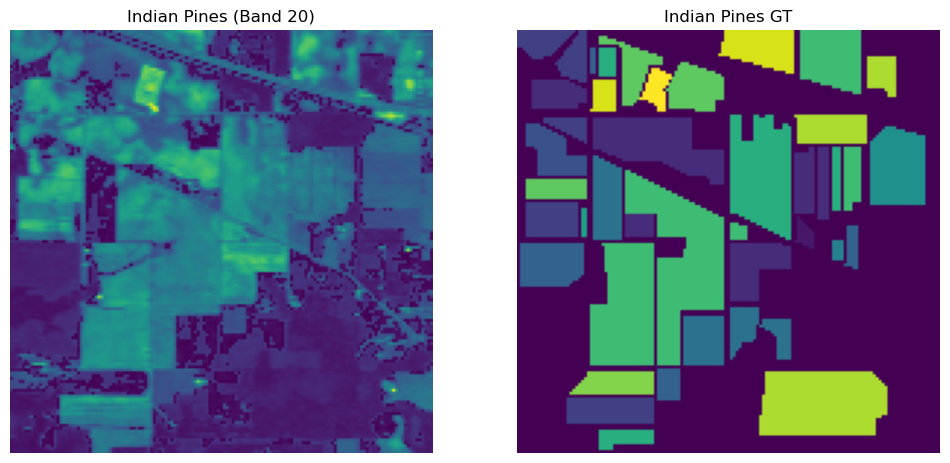

In [52]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io

DATASETS_FOLDER = "/home/edwinacevedo/datasets/hsi"
BAND_INDEX = 20

# Load the data (if not already loaded)
indian_pines = scipy.io.loadmat(DATASETS_FOLDER + '/Indian_pines_corrected.mat')['indian_pines_corrected']
indian_pines_gt = scipy.io.loadmat(DATASETS_FOLDER + '/Indian_pines_gt.mat')['indian_pines_gt']

# One band visualization
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(indian_pines[:, :, BAND_INDEX])
plt.title(f'Indian Pines (Band {BAND_INDEX})')
plt.axis('off')

# Groundtruth
plt.subplot(1, 2, 2)
plt.imshow(indian_pines_gt)
plt.title('Indian Pines GT')
plt.axis('off')
plt.show()

#### RGB Visualiztion

For RGB visualiziation you must select the bands that correspond to the red, green and blue channels. Also False RGB composites are used to visualize and analyzing the data.

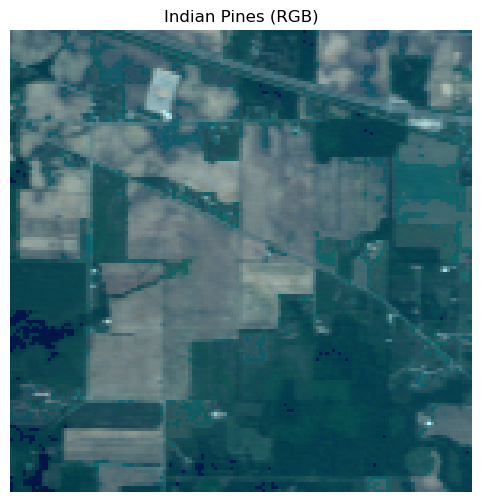

In [77]:
# Define the bands to use for RGB
rgb_bands = [15, 10, 4] # False RGB Bands
rgb_bands = [26, 14, 8] # False RGB Bands

# Create RGB image
rgb_image = indian_pines[:, :, rgb_bands]

# Normalize to [0, 1]
rgb_image = (rgb_image - rgb_image.min()) / (rgb_image.max() - rgb_image.min())

# Display RGB image
plt.figure(figsize=(8, 6))
plt.imshow(rgb_image)
plt.title('Indian Pines (RGB)')
plt.axis('off')
plt.show()

#### Ground Truth Classes Visualization

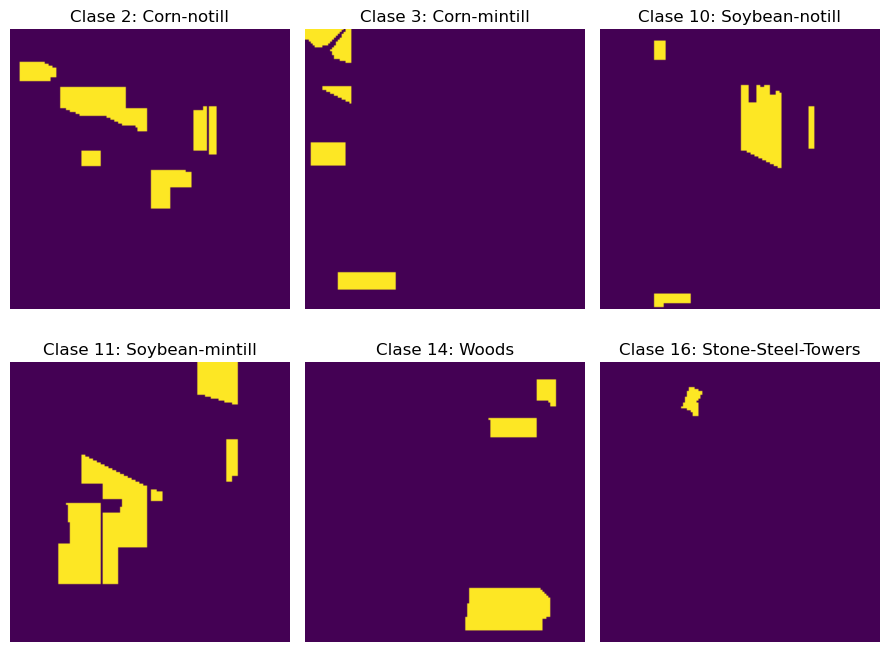

In [76]:
# Indian Pines dataset class names
class_names = {
    1: "Alfalfa", 2: "Corn-notill", 3: "Corn-mintill", 4: "Corn",
    5: "Grass-pasture", 6: "Grass-trees", 7: "Grass-pasture-mowed",
    8: "Hay-windrowed", 9: "Oats", 10: "Soybean-notill",
    11: "Soybean-mintill", 12: "Soybean-clean", 13: "Wheat",
    14: "Woods", 15: "Buildings-Grass-Trees-Drives", 16: "Stone-Steel-Towers"
}

# Select the classes to plot
selected_classes = [2, 3, 10, 11, 14, 16]

# Plot the selected classes
fig, axes = plt.subplots(2, 3, figsize=(9, 7))
axes = axes.ravel() # Flatten the axes array

for i, class_id in enumerate(selected_classes):
    class_mask = np.where(indian_pines_gt == class_id, 1, 0)
    
    axes[i].imshow(class_mask, cmap='viridis')
    axes[i].set_title(f"Clase {class_id}: {class_names[class_id]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

## Pavia Univerity

Is a dataset of hyperspectral images of Pavia, in Northen Italy, taken by the ROSIS sensor (Reflective Optics System Imaging Spectrometer) of the University of Pavia by the *Telecommunications and Remote Sensing Laboratory* in 2001.

| Characteristic | Value |
| :--- | :--- |
| Number of categories | 9 |
| Data size | 610 x 340 pixels |
| Spectral bands | 103 |
| Number of pixels | 42776 |
| Spatial Resolution | 1.3 meters per pixel |
| Wavelength range | 430 - 850 nm ?|

This dataset contains 9 clases of mostly urban types.

| Class | Name |
| :--- | :--- |
| 1 | Asphalt |
| 2 | Meadows |
| 3 | Gravel |
| 4 | Trees |
| 5 | Painted metal sheets |
| 6 | Bare Soil |
| 7 | Bitumen |
| 8 | Self-Blocking Bricks |
| 9 | Shadows |

### Downloading
For download this dataset execute the followinng code block:

In [1]:
import scipy.io
import os
import requests

DATASETS_FOLDER = "/home/edwinacevedo/datasets/hsi"

if not os.path.exists(DATASETS_FOLDER):
    os.makedirs(DATASETS_FOLDER)

def download_file(url, filename):
    if not os.path.exists(filename):
        response = requests.get(url)
        with open(filename, 'wb') as f:
            f.write(response.content)
        print(f"Downloaded {filename}")
    else:
        print(f"{filename} already exists")

# URLs for PaviaU dataset
data_url = 'http://www.ehu.eus/ccwintco/uploads/e/ee/PaviaU.mat'
gt_url = 'http://www.ehu.eus/ccwintco/uploads/5/50/PaviaU_gt.mat'

download_file(data_url, DATASETS_FOLDER + '/PaviaU.mat')
download_file(gt_url, DATASETS_FOLDER + '/PaviaU_gt.mat')

# Load the data
paviaU = scipy.io.loadmat(DATASETS_FOLDER + '/PaviaU.mat')['paviaU']
paviaU_gt = scipy.io.loadmat(DATASETS_FOLDER + '/PaviaU_gt.mat')['paviaU_gt']

print(f"Data shape: {paviaU.shape}")
print(f"Ground truth shape: {paviaU_gt.shape}")

/home/edwinacevedo/datasets/hsi/PaviaU.mat already exists
/home/edwinacevedo/datasets/hsi/PaviaU_gt.mat already exists
Data shape: (610, 340, 103)
Ground truth shape: (610, 340)


### Visualizing
Once you downloaded and check if it was rightly downloaded, you can proceed to open and visualize the images (Sensed image and groundtruth) with the following code:

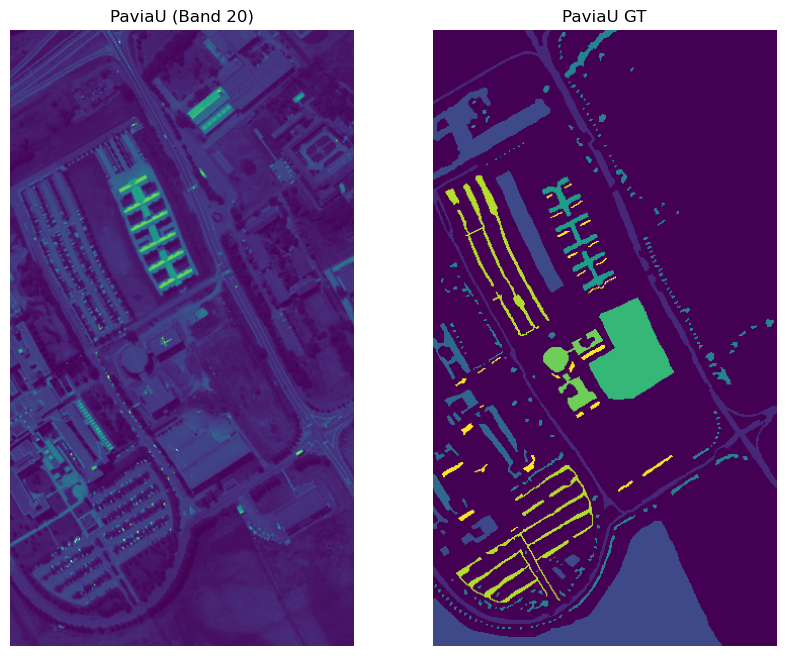

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.io

DATASETS_FOLDER = "/home/edwinacevedo/datasets/hsi"
BAND_INDEX = 20

# Load the data (if not already loaded)
paviaU = scipy.io.loadmat(DATASETS_FOLDER + '/PaviaU.mat')['paviaU']
paviaU_gt = scipy.io.loadmat(DATASETS_FOLDER + '/PaviaU_gt.mat')['paviaU_gt']

# One band visualization
plt.figure(figsize=(10, 8))
plt.subplot(1, 2, 1)
plt.imshow(paviaU[:, :, BAND_INDEX])
plt.title(f'PaviaU (Band {BAND_INDEX})')
plt.axis('off')

# Groundtruth
plt.subplot(1, 2, 2)
plt.imshow(paviaU_gt)
plt.title('PaviaU GT')
plt.axis('off')
plt.show()

#### RGB Visualiztion

For RGB visualiziation you must select the bands that correspond to the red, green and blue channels. Also False RGB composites are used to visualize and analyzing the data.

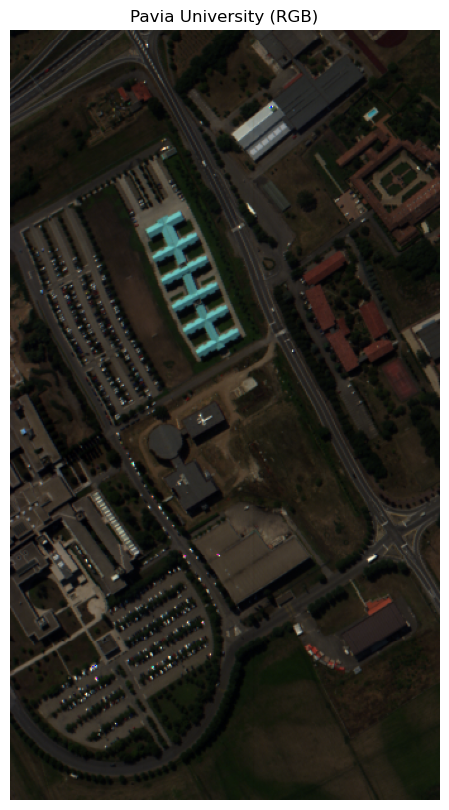

In [78]:
# Define the bands to use for RGB
rgb_bands = [46, 27, 10]

# Create RGB image
rgb_image = paviaU[:, :, rgb_bands]

# Normalize to [0, 1]
rgb_image = (rgb_image  - rgb_image.min()) / (rgb_image.max() - rgb_image.min())

# Display RGB image
plt.figure(figsize=(12, 10))
plt.imshow(rgb_image)   
plt.title('Pavia University (RGB)')
plt.axis('off')
plt.show()

#### Ground Truth Classes Visualization

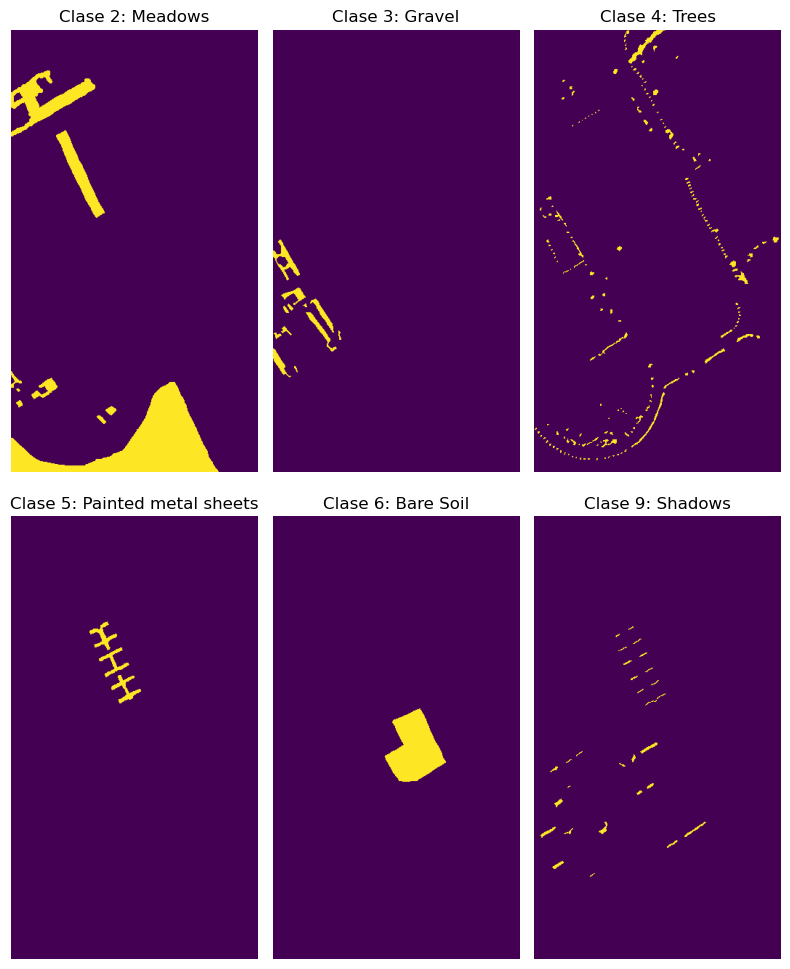

In [70]:
# Pavia University dataset class names
class_names = {
    1: "Asphalt", 2: "Meadows", 3: "Gravel", 4: "Trees",
    5: "Painted metal sheets", 6: "Bare Soil", 7: "Bitumen",
    8: "Self-Blocking Bricks", 9: "Shadows"
}

# Select the classes to plot
selected_classes = [2, 3, 4, 5, 6, 9]

# Plot the selected classes
fig, axes = plt.subplots(2, 3, figsize=(8, 10))
axes = axes.ravel() # Flatten the axes array

for i, class_id in enumerate(selected_classes):
    class_mask = np.where(paviaU_gt == class_id, 1, 0)
    
    axes[i].imshow(class_mask, cmap='viridis')
    axes[i].set_title(f"Clase {class_id}: {class_names[class_id]}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()